# WEC Power Estimation: Leixões Sea-State Characterization and Generic Power Matrix

This notebook uses the processed Leixões buoy sea-state table prepared in [Notebook 01](01_wave_data_preparation.ipynb).

The goal is to explore the available wave-height, period, direction, and extreme-wave variables before converting the sea-state record into a simplified estimated WEC electrical power signal.

The notebook is organized in three phases:

1. **Site characterization** — visualize the observed wave conditions and directionality.
2. **Sea-state consistency and operating-condition checks** — compare related height and period variables and define simple flags for interpretation.
3. **Simplified WEC electrical power estimation** — use a generic power-matrix-style approach to estimate an illustrative WEC power-output signal.

The estimated WEC power signal is intended for later forecasting, uncertainty, and storage-smoothing examples. It is not a validated device model or detailed WEC hydrodynamic simulation.


## Phase 1 — Site characterization

This phase gives a first visual overview of the Leixões buoy sea-state record prepared in [Notebook 01](01_wave_data_preparation.ipynb).

We start with the two main variables that will later drive the simplified WEC power estimate:

- `hm0_m`: spectral significant wave height
- `tp_s`: peak wave period

Missing values are kept as gaps in the plots.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mhkit.wave import graphics as wave_graphics

# Paths
PROCESSED_DATA_PATH = Path("../data/processed/leixoes_wave_30min_processed.parquet")
FIGURE_DIR = Path("../outputs/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load processed sea-state table from Notebook 01
wave_df = pd.read_parquet(PROCESSED_DATA_PATH)

wave_df["time"] = pd.to_datetime(wave_df["time"])
wave_df = wave_df.sort_values("time").reset_index(drop=True)

### Time series overview of wave height and peak period

This plot shows how significant wave height and peak period vary through the available February–June 2025 record.

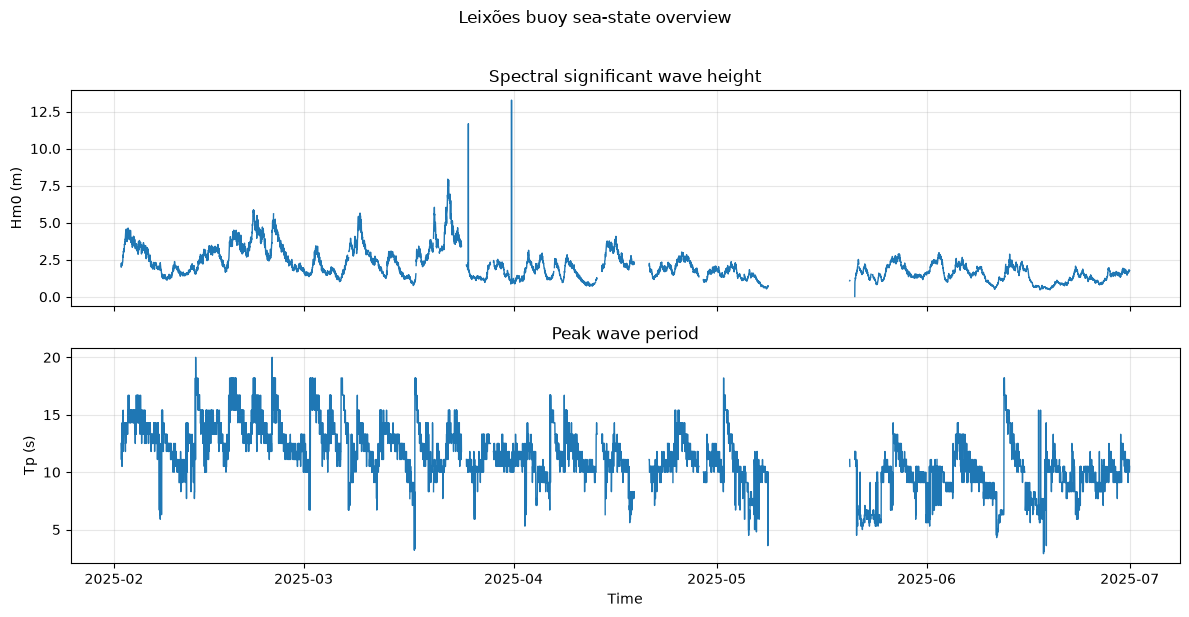

In [3]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 6),
    sharex=True,
)

axes[0].plot(wave_df["time"], wave_df["hm0_m"], linewidth=1.0)
axes[0].set_ylabel("Hm0 (m)")
axes[0].set_title("Spectral significant wave height")

axes[1].plot(wave_df["time"], wave_df["tp_s"], linewidth=1.0)
axes[1].set_ylabel("Tp (s)")
axes[1].set_xlabel("Time")
axes[1].set_title("Peak wave period")

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.suptitle("Leixões buoy sea-state overview", y=1.02)
fig.tight_layout()

plt.show()

### Sea-state cloud: wave height versus peak period

The simplified WEC power estimate will mainly depend on wave height and wave period.  
This scatter plot shows the observed `hm0_m`–`tp_s` combinations in the Leixões record.

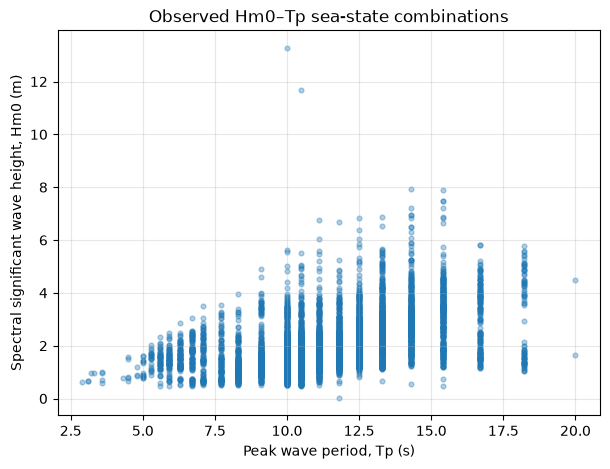

In [5]:
sea_state_df = wave_df.dropna(subset=["hm0_m", "tp_s"]).copy()

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    sea_state_df["tp_s"],
    sea_state_df["hm0_m"],
    s=12,
    alpha=0.35,
)

ax.set_xlabel("Peak wave period, Tp (s)")
ax.set_ylabel("Spectral significant wave height, Hm0 (m)")
ax.set_title("Observed Hm0–Tp sea-state combinations")
ax.grid(True, alpha=0.3)

plt.show()

Most observed sea states are concentrated between about 5–17 s peak period and below roughly 5 m significant wave height. A few much larger wave-height values appear as energetic events or possible extremes in the record.

### Wave direction and directional spreading

Wave direction helps describe where the observed waves mainly come from.  
Here, a wave rose summarizes peak wave direction together with significant wave-height classes.

Directional spreading is shown separately because it describes how concentrated or broad the wave field is around the peak direction.

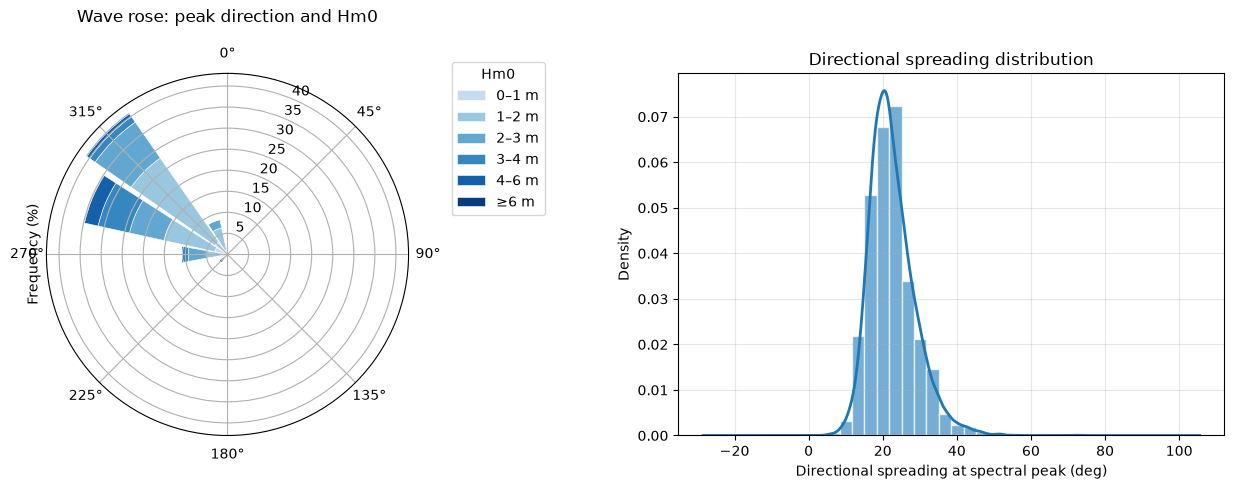

In [11]:
direction_df = wave_df.dropna(subset=["dir_peak_deg", "hm0_m"]).copy()
spread_df = wave_df.dropna(subset=["spread_peak_deg"]).copy()

# Direction is circular, so keep values in [0, 360).
direction_df["dir_peak_deg"] = direction_df["dir_peak_deg"] % 360

# Direction sectors for the rose plot.
sector_width_deg = 22.5
direction_centers = np.arange(0, 360, sector_width_deg)

direction_bin_idx = np.floor(
    ((direction_df["dir_peak_deg"] + sector_width_deg / 2) % 360) / sector_width_deg
).astype(int)

direction_df["direction_bin_deg"] = direction_bin_idx * sector_width_deg

# Wave-height classes.
hm0_bins = [0, 1, 2, 3, 4, 6, np.inf]
hm0_labels = ["0–1 m", "1–2 m", "2–3 m", "3–4 m", "4–6 m", "≥6 m"]

direction_df["hm0_class"] = pd.cut(
    direction_df["hm0_m"],
    bins=hm0_bins,
    labels=hm0_labels,
    right=False,
)

rose_counts = pd.crosstab(
    direction_df["direction_bin_deg"],
    direction_df["hm0_class"],
)

rose_counts = rose_counts.reindex(
    index=direction_centers,
    columns=hm0_labels,
    fill_value=0,
)

rose_freq = 100 * rose_counts / rose_counts.values.sum()

# Light-to-dark blue colors for increasing Hm0 classes.
hm0_colors = plt.cm.Blues(np.linspace(0.25, 0.95, len(hm0_labels)))

fig = plt.figure(figsize=(13, 5))

# Wave rose
ax1 = fig.add_subplot(1, 2, 1, projection="polar")

theta = np.deg2rad(direction_centers)
bar_width = np.deg2rad(sector_width_deg * 0.9)
bottom = np.zeros(len(direction_centers))

for hm0_class, color in zip(hm0_labels, hm0_colors):
    values = rose_freq[hm0_class].values
    ax1.bar(
        theta,
        values,
        width=bar_width,
        bottom=bottom,
        label=hm0_class,
        color=color,
        edgecolor="white",
        linewidth=0.4,
    )
    bottom += values

ax1.set_theta_zero_location("N")
ax1.set_theta_direction(-1)
ax1.set_title("Wave rose: peak direction and Hm0", pad=18)
ax1.set_ylabel("Frequency (%)")
ax1.legend(title="Hm0", bbox_to_anchor=(1.10, 1.05), loc="upper left")

# Directional spreading histogram + density curve
ax2 = fig.add_subplot(1, 2, 2)

spread_values = spread_df["spread_peak_deg"].dropna()

ax2.hist(
    spread_values,
    bins=20,
    density=True,
    color=plt.cm.Blues(0.65),
    edgecolor="white",
    alpha=0.7,
)

spread_values.plot.kde(ax=ax2, linewidth=2)

ax2.set_xlabel("Directional spreading at spectral peak (deg)")
ax2.set_ylabel("Density")
ax2.set_title("Directional spreading distribution")
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

The wave rose shows that most recorded peak wave directions are concentrated around the northwest sector, with larger wave-height classes also appearing mainly from that direction. The spreading distribution is centred around roughly 20–30°, suggesting that many observed sea states have a fairly concentrated peak direction rather than very broad directional spreading.

## Phase 2 — Sea-state consistency and operating-condition checks

This phase compares related wave-height and wave-period variables before using them in the simplified WEC power-estimation step.

We start by checking how the main height variable `hm0_m` relates to the secondary and extreme-wave height variables.

### Wave-height variable checks

`hm0_m` is the main wave-height variable used later.  
Here it is compared with:

- `h13_m`: average height of the highest one-third waves
- `hmax_m`: maximum zero-crossing wave height

These plots help check whether the related height variables behave consistently.

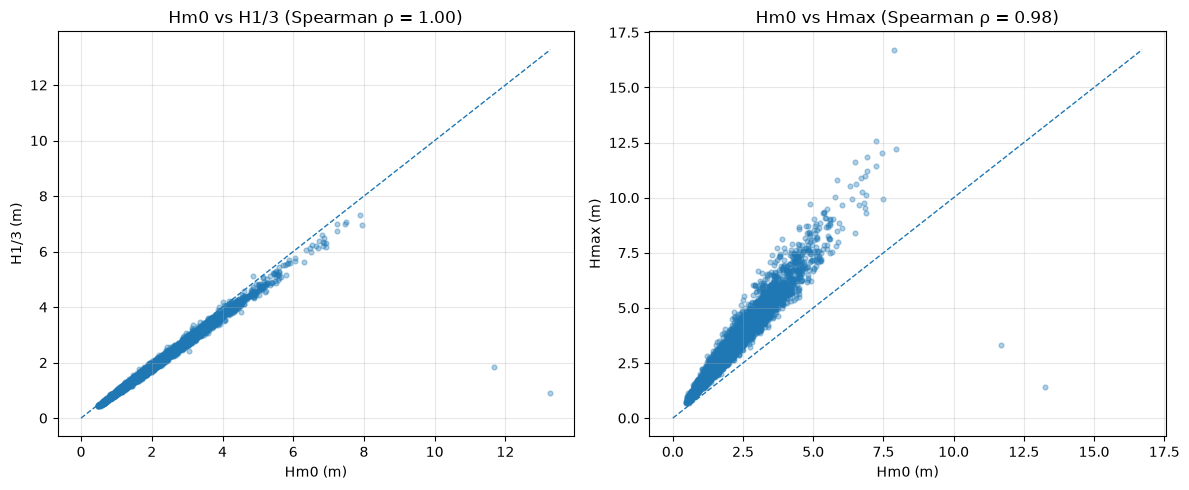

In [13]:
from scipy.stats import spearmanr

height_df = wave_df.dropna(subset=["hm0_m", "h13_m", "hmax_m"]).copy()

rho_h13, _ = spearmanr(height_df["hm0_m"], height_df["h13_m"])
rho_hmax, _ = spearmanr(height_df["hm0_m"], height_df["hmax_m"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Hm0 vs H1/3
axes[0].scatter(
    height_df["hm0_m"],
    height_df["h13_m"],
    s=12,
    alpha=0.35,
)

max_h13 = np.nanmax([height_df["hm0_m"].max(), height_df["h13_m"].max()])
axes[0].plot([0, max_h13], [0, max_h13], linestyle="--", linewidth=1)

axes[0].set_xlabel("Hm0 (m)")
axes[0].set_ylabel("H1/3 (m)")
axes[0].set_title(f"Hm0 vs H1/3 (Spearman ρ = {rho_h13:.2f})")
axes[0].grid(True, alpha=0.3)

# Hm0 vs Hmax
axes[1].scatter(
    height_df["hm0_m"],
    height_df["hmax_m"],
    s=12,
    alpha=0.35,
)

max_hmax = np.nanmax([height_df["hm0_m"].max(), height_df["hmax_m"].max()])
axes[1].plot([0, max_hmax], [0, max_hmax], linestyle="--", linewidth=1)

axes[1].set_xlabel("Hm0 (m)")
axes[1].set_ylabel("Hmax (m)")
axes[1].set_title(f"Hm0 vs Hmax (Spearman ρ = {rho_hmax:.2f})")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

`hm0_m` and `h13_m` are almost identical in rank order, which is expected because both describe significant wave-height scale. `hmax_m` is also strongly related to `hm0_m`, but it is generally larger and more scattered because it represents maximum individual wave height rather than the average sea-state height.

### Wave-period variable checks

`tp_s` is the main period variable available for the later simplified WEC estimate.  
Here it is compared with two secondary period descriptors:

- `tm02_s`: spectral moments `(0,2)` wave period
- `tz_s`: average zero-crossing wave period

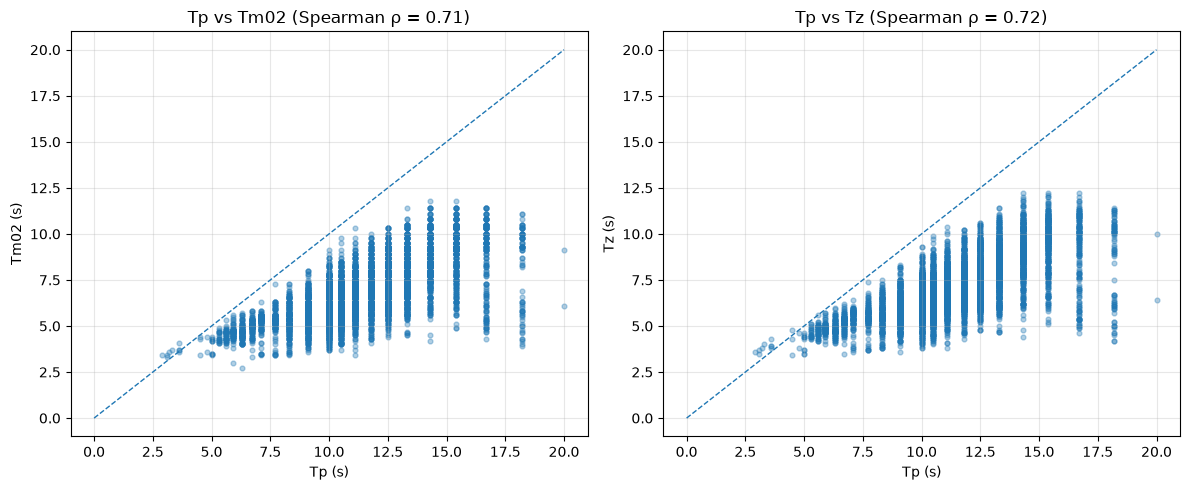

In [14]:
period_df = wave_df.dropna(subset=["tp_s", "tm02_s", "tz_s"]).copy()

rho_tm02, _ = spearmanr(period_df["tp_s"], period_df["tm02_s"])
rho_tz, _ = spearmanr(period_df["tp_s"], period_df["tz_s"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Tp vs Tm02
axes[0].scatter(
    period_df["tp_s"],
    period_df["tm02_s"],
    s=12,
    alpha=0.35,
)

max_tm02 = np.nanmax([period_df["tp_s"].max(), period_df["tm02_s"].max()])
axes[0].plot([0, max_tm02], [0, max_tm02], linestyle="--", linewidth=1)

axes[0].set_xlabel("Tp (s)")
axes[0].set_ylabel("Tm02 (s)")
axes[0].set_title(f"Tp vs Tm02 (Spearman ρ = {rho_tm02:.2f})")
axes[0].grid(True, alpha=0.3)

# Tp vs Tz
axes[1].scatter(
    period_df["tp_s"],
    period_df["tz_s"],
    s=12,
    alpha=0.35,
)

max_tz = np.nanmax([period_df["tp_s"].max(), period_df["tz_s"].max()])
axes[1].plot([0, max_tz], [0, max_tz], linestyle="--", linewidth=1)

axes[1].set_xlabel("Tp (s)")
axes[1].set_ylabel("Tz (s)")
axes[1].set_title(f"Tp vs Tz (Spearman ρ = {rho_tz:.2f})")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

`tm02_s` and `tz_s` are both shorter-period descriptors than `tp_s`. `tp_s` is the period at the spectral peak, while `tm02_s` is a spectral-moment-based mean period and `tz_s` is the average zero-crossing period. Both variables increase broadly with `tp_s`, but the relationship is more scattered than for the height variables. This is expected because peak period describes the dominant wave component, while mean/zero-crossing periods summarize the broader sea state.

### Simple wave-height condition flags

Before estimating WEC power, we define a few simple wave-height flags for interpretation.

These thresholds are illustrative and can be adjusted later. They help mark calm, energetic, and high-wave conditions in the available record.

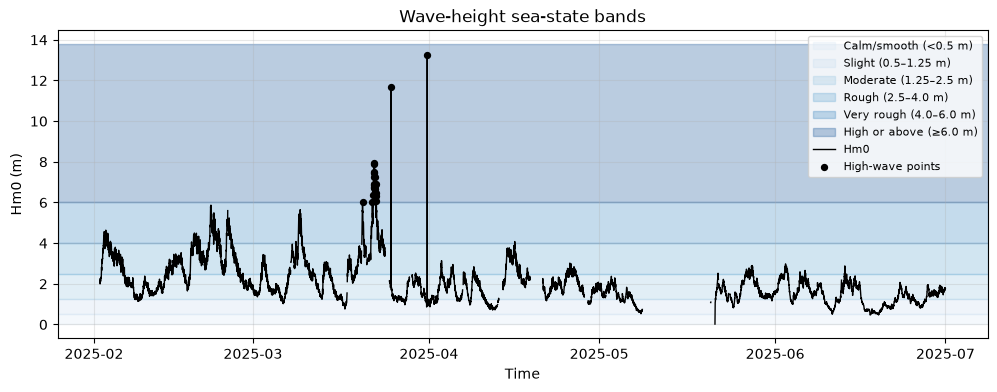

In [17]:
condition_df = wave_df.copy()

# Descriptive sea-state bands based on common WMO/Douglas-style Hs ranges.
sea_state_bands = [
    (0.0, 0.5, "Calm/smooth (<0.5 m)", plt.cm.Blues(0.15)),
    (0.5, 1.25, "Slight (0.5–1.25 m)", plt.cm.Blues(0.25)),
    (1.25, 2.5, "Moderate (1.25–2.5 m)", plt.cm.Blues(0.40)),
    (2.5, 4.0, "Rough (2.5–4.0 m)", plt.cm.Blues(0.55)),
    (4.0, 6.0, "Very rough (4.0–6.0 m)", plt.cm.Blues(0.70)),
    (6.0, np.nanmax(condition_df["hm0_m"]) + 0.5, "High or above (≥6.0 m)", plt.cm.Blues(0.90)),
]

condition_df["high_wave_flag"] = condition_df["hm0_m"] >= 6.0

fig, ax = plt.subplots(figsize=(12, 4))

# Background sea-state bands
for lower, upper, label, color in sea_state_bands:
    ax.axhspan(
        lower,
        upper,
        color=color,
        alpha=0.28,
        label=label,
    )

# Main Hm0 line
ax.plot(
    condition_df["time"],
    condition_df["hm0_m"],
    color="black",
    linewidth=1.0,
    label="Hm0",
)

# High-wave points
ax.scatter(
    condition_df.loc[condition_df["high_wave_flag"], "time"],
    condition_df.loc[condition_df["high_wave_flag"], "hm0_m"],
    s=18,
    color="black",
    zorder=3,
    label="High-wave points",
)

ax.set_xlabel("Time")
ax.set_ylabel("Hm0 (m)")
ax.set_title("Wave-height sea-state bands")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=8)

plt.show()

This plot uses descriptive sea-state bands based on common [WMO/Douglas-style significant-wave-height ranges](https://www.nodc.noaa.gov/gtspp/document/codetbls/wmocodes/table3700.html). These bands are used only to interpret the observed wave record; they are not WEC operating limits.

Most of the record falls within the slight to rough ranges, with fewer periods reaching the very rough and high-wave bands. The highest wave events appear concentrated around late March to early April.

### Adding descriptive sea-state flags

The sea-state bands are kept as simple descriptive labels.  
They may help later when interpreting estimated WEC power values, but they are not device-specific operating limits.

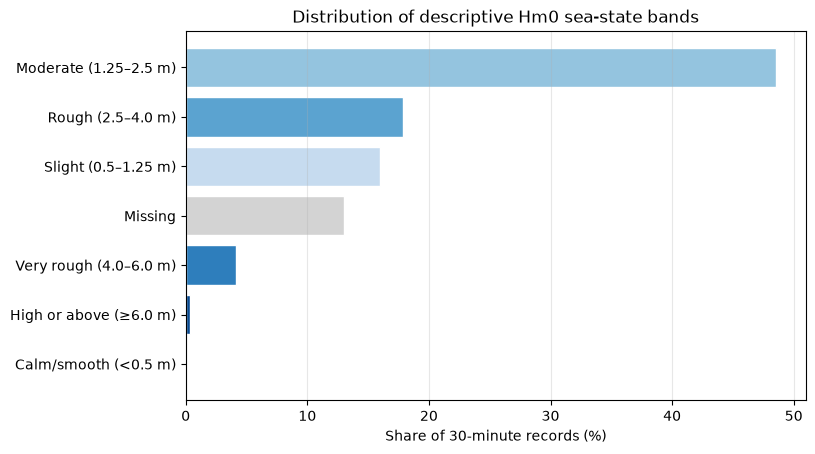

In [19]:
# Keep descriptive sea-state labels in the main dataframe.
sea_state_bins = [0.0, 0.5, 1.25, 2.5, 4.0, 6.0, np.inf]

sea_state_labels = [
    "calm_smooth",
    "slight",
    "moderate",
    "rough",
    "very_rough",
    "high_or_above",
]

sea_state_display_labels = {
    "calm_smooth": "Calm/smooth (<0.5 m)",
    "slight": "Slight (0.5–1.25 m)",
    "moderate": "Moderate (1.25–2.5 m)",
    "rough": "Rough (2.5–4.0 m)",
    "very_rough": "Very rough (4.0–6.0 m)",
    "high_or_above": "High or above (≥6.0 m)",
    "missing": "Missing",
}

sea_state_colors = {
    "calm_smooth": plt.cm.Blues(0.15),
    "slight": plt.cm.Blues(0.25),
    "moderate": plt.cm.Blues(0.40),
    "rough": plt.cm.Blues(0.55),
    "very_rough": plt.cm.Blues(0.70),
    "high_or_above": plt.cm.Blues(0.90),
    "missing": "lightgrey",
}

wave_df["sea_state_hm0_band"] = pd.cut(
    wave_df["hm0_m"],
    bins=sea_state_bins,
    labels=sea_state_labels,
    right=False,
)

wave_df["high_wave_flag"] = wave_df["hm0_m"] >= 6.0
wave_df["very_rough_or_higher_flag"] = wave_df["hm0_m"] >= 4.0

sea_state_counts = (
    wave_df["sea_state_hm0_band"]
    .astype(object)
    .where(wave_df["sea_state_hm0_band"].notna(), "missing")
    .value_counts()
)

sea_state_percent = 100 * sea_state_counts / len(wave_df)

sea_state_summary = (
    pd.DataFrame(
        {
            "band": sea_state_counts.index,
            "count": sea_state_counts.values,
            "percent": sea_state_percent.values,
        }
    )
    .sort_values("percent", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 4.8))

ax.barh(
    sea_state_summary["band"].map(sea_state_display_labels),
    sea_state_summary["percent"],
    color=sea_state_summary["band"].map(sea_state_colors),
    edgecolor="white",
)

ax.set_xlabel("Share of 30-minute records (%)")
ax.set_ylabel("")
ax.set_title("Distribution of descriptive Hm0 sea-state bands")
ax.grid(True, axis="x", alpha=0.3)

plt.show()

## Phase 3 — Simplified WEC electrical power estimation

This phase converts the cleaned sea-state record into an illustrative WEC electrical power estimate.

Because the processed buoy table does not include full wave spectra or measured WEC power, this notebook uses a simplified power-matrix-style approach. The result is a transparent estimated power signal for later forecasting and storage-smoothing examples, not a validated device model.

### Approximate energy period `te_approx_s` and wave power flux

A WEC power matrix is commonly described using wave height and a wave-period variable.  
Here, `tp_s` is the available peak-period measurement. Because the direct energy period was not available in the processed buoy data, an approximate energy period `te_approx_s` is derived from `tp_s`.

For a Pierson–Moskowitz-type spectrum, a commonly used approximation is:

$$
T_e \approx 0.86\,T_p
$$

The exact ratio depends on the wave spectrum; for example, Pierson–Moskowitz and JONSWAP assumptions can give different values. This approximation is therefore used only as a simple supporting variable for this Stage 1 workflow. See Guillou (2020) for discussion of estimating wave-energy flux from significant wave height and peak period, including the use of $( \alpha = 0.86 )$ for a Pierson–Moskowitz spectrum: [Estimating wave energy flux from significant wave height and peak period](https://doi.org/10.1016/j.renene.2020.03.124).

The approximate deep-water wave power flux is then estimated as:

$$
J \approx 0.49\,H_{m0}^{2}\,T_e
$$

where $J$ is in kW/m, $H_{m0}$ is in metres, and $T_e$ is in seconds.

The wave power flux estimate is used as a resource diagnostic, not as the final WEC electrical power.

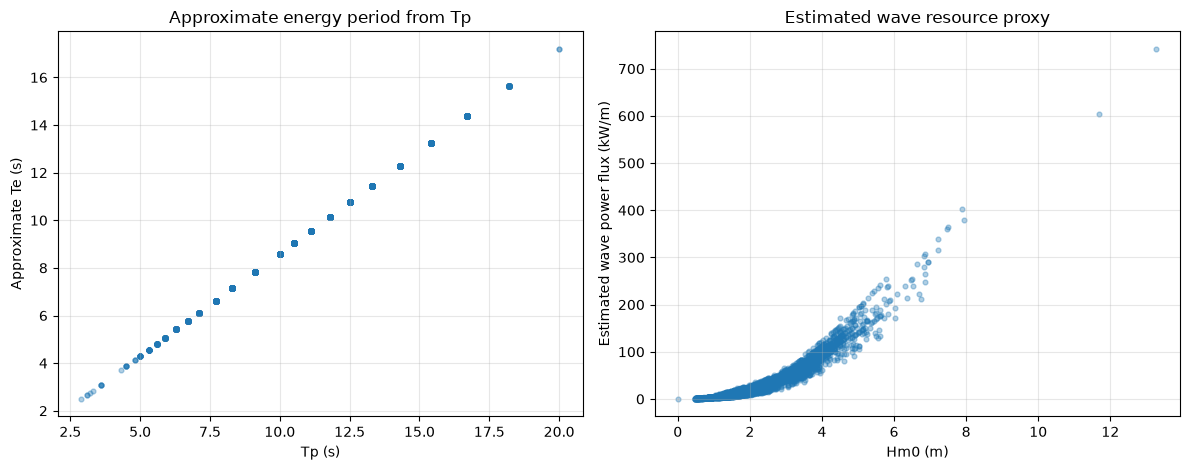

In [20]:
wec_df = wave_df.copy()

# Approximate energy period from peak period.
# This is a simple assumption because VTM10 / direct energy period was not available.
te_from_tp_factor = 0.86

wec_df["te_approx_s"] = te_from_tp_factor * wec_df["tp_s"]

# Deep-water wave power flux approximation:
# J [kW/m] ≈ 0.49 * Hm0^2 * Te
wec_df["wave_power_flux_kw_m_estimated"] = (
    0.49 * wec_df["hm0_m"] ** 2 * wec_df["te_approx_s"]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# Tp vs approximate Te
axes[0].scatter(
    wec_df["tp_s"],
    wec_df["te_approx_s"],
    s=12,
    alpha=0.35,
)

axes[0].set_xlabel("Tp (s)")
axes[0].set_ylabel("Approximate Te (s)")
axes[0].set_title("Approximate energy period from Tp")
axes[0].grid(True, alpha=0.3)

# Hm0 vs estimated wave power flux
axes[1].scatter(
    wec_df["hm0_m"],
    wec_df["wave_power_flux_kw_m_estimated"],
    s=12,
    alpha=0.35,
)

axes[1].set_xlabel("Hm0 (m)")
axes[1].set_ylabel("Estimated wave power flux (kW/m)")
axes[1].set_title("Estimated wave resource proxy")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### Defining simplified WEC assumptions

The estimated WEC power signal is based on a generic illustrative response, not a specific device.

The assumptions below are chosen to stay within a realistic small/medium WEC scale while keeping the model transparent. A rated-power scale of 250 kW is consistent with published and database examples of devices such as AquaBuOY, which is commonly listed with a 250 kW rating. The Pelamis P-750 also used three 250 kW power-conversion modules, although the complete Pelamis device was rated at 750 kW.

The use of a power matrix is also consistent with common WEC performance-estimation practice. For example, Pelamis documentation describes a power matrix over significant wave height and power period, and several WEC assessment studies estimate converted power by combining buoy or hindcast sea states with device conversion matrices.

The high-wave threshold is treated as an illustrative power-limiting / cut-out threshold. It is loosely motivated by Pelamis documentation that reports hydrostatic power limiting above about 6–7 m significant wave height.

The remaining values, including the preferred period and response width, are modelling choices for this notebook. They are not calibrated to a validated device. They define a smooth generic response shape for creating a transparent power-like signal for later forecasting and storage-smoothing examples.

References:

- [AquaBuOY device entry, PRIMRE / OpenEI](https://openei.org/wiki/PRIMRE/Databases/Projects_Database/Devices/AquaBuOY)
- [Pelamis P-750 brochure](https://bravenewclimate.com/files/media/pelamisbrochure.pdf)
- [Assessment of WECs based on historical buoy data and conversion matrices](https://www.mdpi.com/2073-4441/15/23/4075)
- [Guillou 2020 — estimating wave energy flux from significant wave height and peak period](https://doi.org/10.1016/j.renene.2020.03.124)

In [24]:
from IPython.display import Markdown, display

# Generic illustrative WEC assumptions.
# These are modelling assumptions, not device-validated parameters.

wec_assumptions = {
    "rated_power_kw": 250.0,
    "cut_in_hm0_m": 0.5,
    "rated_hm0_m": 4.0,
    "storm_cutout_hm0_m": 6.0,
    "preferred_te_s": 9.0,
    "period_response_width_s": 2.5,
}

wec_assumptions_table = pd.DataFrame(
    {
        "Assumption": [
            "Rated electrical power",
            "Cut-in wave height",
            "Rated-response wave height",
            "High-wave limiting threshold",
            "Preferred energy period",
            "Period response width",
        ],
        "Value": [
            f"{wec_assumptions['rated_power_kw']:.0f} kW",
            f"{wec_assumptions['cut_in_hm0_m']:.1f} m",
            f"{wec_assumptions['rated_hm0_m']:.1f} m",
            f"{wec_assumptions['storm_cutout_hm0_m']:.1f} m",
            f"{wec_assumptions['preferred_te_s']:.1f} s",
            f"{wec_assumptions['period_response_width_s']:.1f} s",
        ],
        "Role": [
            "Upper limit for estimated electrical power",
            "Below this, estimated WEC power is set to zero",
            "Wave-height scale where output approaches rated power",
            "Above this, estimated WEC power is set to zero",
            "Period where the generic response is centred",
            "Controls how quickly response decreases away from the preferred period",
        ],
    }
)

display(Markdown(wec_assumptions_table.to_markdown(index=False)))

| Assumption                   | Value   | Role                                                                   |
|:-----------------------------|:--------|:-----------------------------------------------------------------------|
| Rated electrical power       | 250 kW  | Upper limit for estimated electrical power                             |
| Cut-in wave height           | 0.5 m   | Below this, estimated WEC power is set to zero                         |
| Rated-response wave height   | 4.0 m   | Wave-height scale where output approaches rated power                  |
| High-wave limiting threshold | 6.0 m   | Above this, estimated WEC power is set to zero                         |
| Preferred energy period      | 9.0 s   | Period where the generic response is centred                           |
| Period response width        | 2.5 s   | Controls how quickly response decreases away from the preferred period |